# AIoT Project

In [ ]:
import os

# basic data engineering
import pandas as pd
import numpy as np
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# db
import pymongo
from bson import ObjectId

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Start time of execution

In [2]:
time_start = time()

## Load configuration

In [133]:
config_path = os.path.join(os.getcwd(), "config.yml")

with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

In [134]:
client = pymongo.MongoClient(config["client"])

In [135]:
db = client[config["db"]]
coll = db[config["col"]]

In [137]:
found_keys = coll.distinct("_id")
print(f'Found {len(found_keys)} keys in the collection')

Found 25 keys in the collection


## Load data

In [ ]:
# scroll up data
scroll_up_keys = list(coll.find({"gesture_id": "scroll-up-index"}))
print(f'Found {len(scroll_up_keys)} keys in the collection')


Found 5 keys in the collection
[{'_id': ObjectId('69f8df70cd8164af26e103ea'), 'data': {'acc_x': [-0.166, -0.181, -0.181, -0.163, -0.151, -0.135, -0.103, -0.08, -0.072, -0.067, -0.054, -0.059, -0.063, -0.059, -0.063, -0.08, -0.089, -0.096, -0.103, -0.113, -0.116, -0.116, -0.123, -0.124, -0.126, -0.126, -0.124, -0.123, -0.117, -0.112, -0.103, -0.096, -0.085, -0.08, -0.079, -0.081, -0.081, -0.08, -0.079, -0.091, -0.109, -0.122, -0.127, -0.131, -0.133, -0.126, -0.123, -0.115, -0.105, -0.101, -0.099, -0.095, -0.096, -0.102, -0.106, -0.109, -0.105, -0.104, -0.102, -0.1, -0.094, -0.093, -0.094, -0.096, -0.084, -0.091, -0.083, -0.078, -0.074, -0.057, -0.058, -0.053, -0.055, -0.055, -0.058, -0.065, -0.082, -0.096, -0.101, -0.103, -0.094, -0.086, -0.083, -0.078, -0.074, -0.075, -0.077, -0.079, -0.083, -0.084, -0.093, -0.106, -0.115, -0.123, -0.13, -0.119, -0.109, -0.096, -0.069, -0.043, -0.035, -0.036, -0.032, -0.045, -0.068, -0.085, -0.115, -0.129, -0.134, -0.163, -0.184, -0.16, -0.113, -0.117,

In [127]:
result = coll.find_one({"_id": ObjectId("69f5195b81682b5d87551932")}, {"data": True, "gesture_id": True})

gesture = pd.DataFrame(result)

data = gesture["data"]
label = gesture["gesture_id"]
df = pd.DataFrame(result['data'])


## Explore the nature of the data

In [130]:
print(df.value_counts)

<bound method DataFrame.value_counts of       acc_x  acc_y  acc_z   gyr_x   gyr_y  gyr_z
0     0.242 -0.394  0.886  -6.098   6.768  3.415
1     0.236 -0.406  0.896  -5.915   6.829  2.622
2     0.262 -0.405  0.910  -4.634   5.671  2.378
3     0.250 -0.409  0.907  -2.866   3.537  2.134
4     0.234 -0.405  0.907  -2.561   1.098  2.195
...     ...    ...    ...     ...     ...    ...
5225  0.351 -0.567  0.759   1.341  14.939 -3.659
5226  0.351 -0.553  0.776  -6.037  19.512 -4.451
5227  0.320 -0.541  0.780 -14.085  19.024 -3.659
5228  0.267 -0.532  0.779 -24.512  16.707 -2.500
5229  0.265 -0.539  0.767     NaN     NaN    NaN

[5230 rows x 6 columns]>


Print Window: 1
Number of samples: 2000
Print Window: 2
Number of samples: 2000
Print Window: 3
Number of samples: 2000
Print Window: 4
Number of samples: 2000
List number of window instances: 4
Number of filtered instances in the list: 4


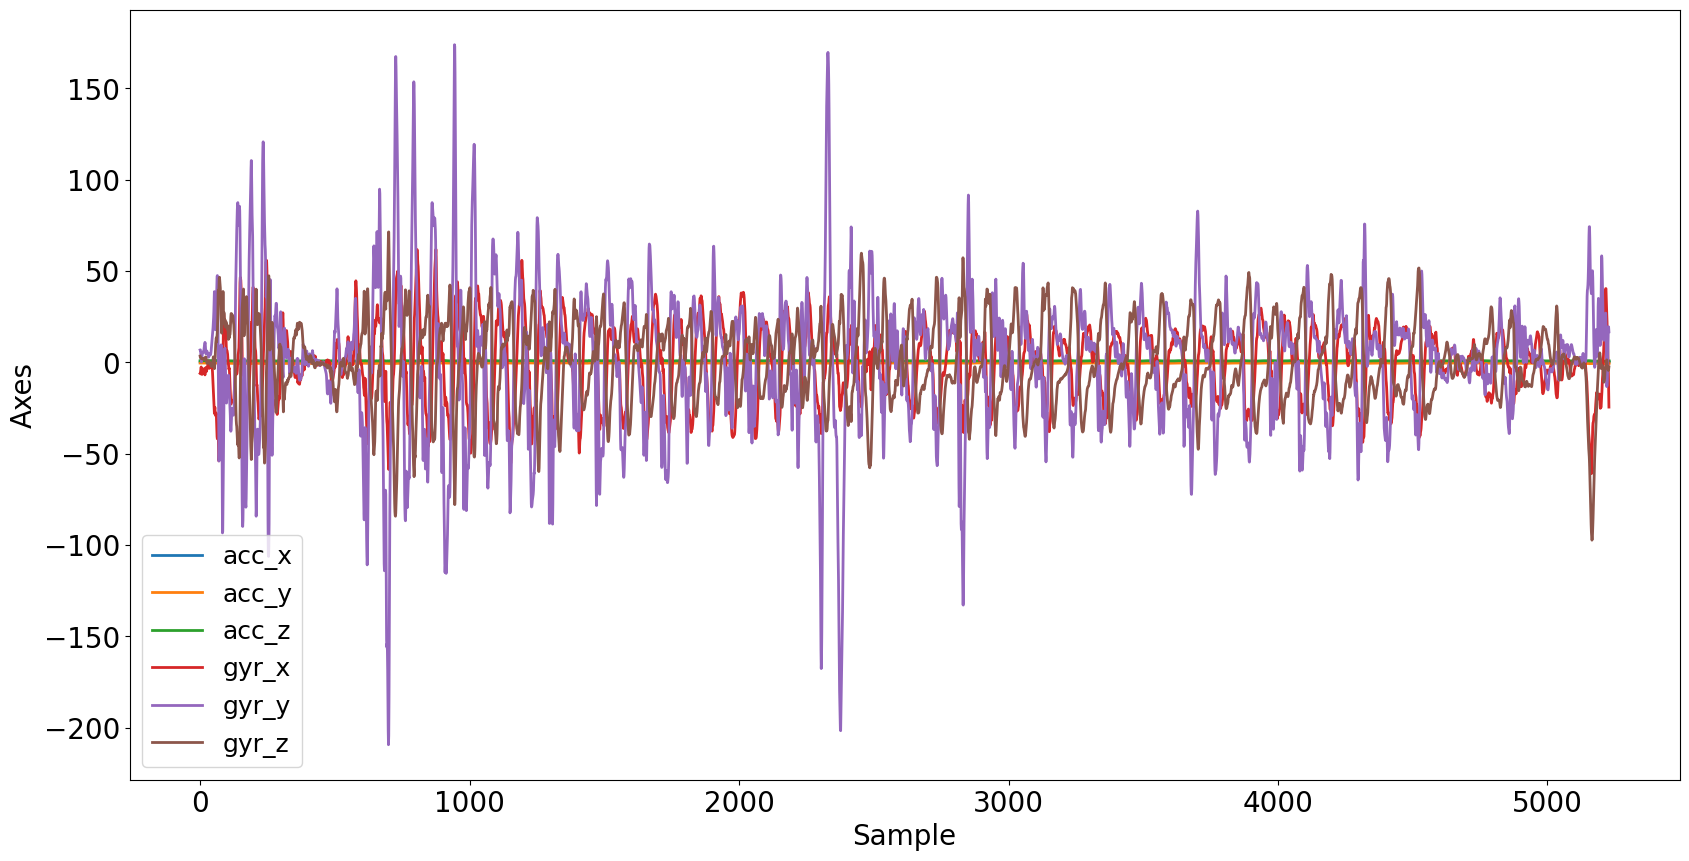

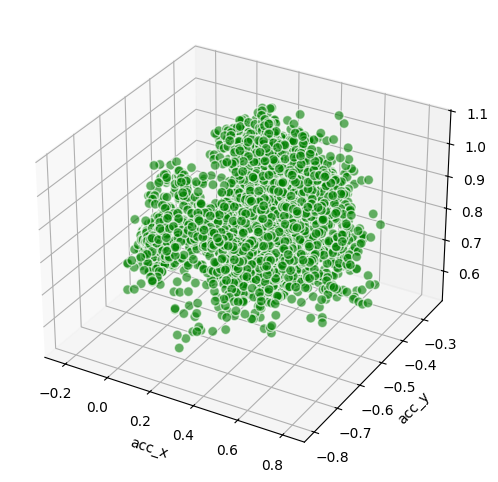

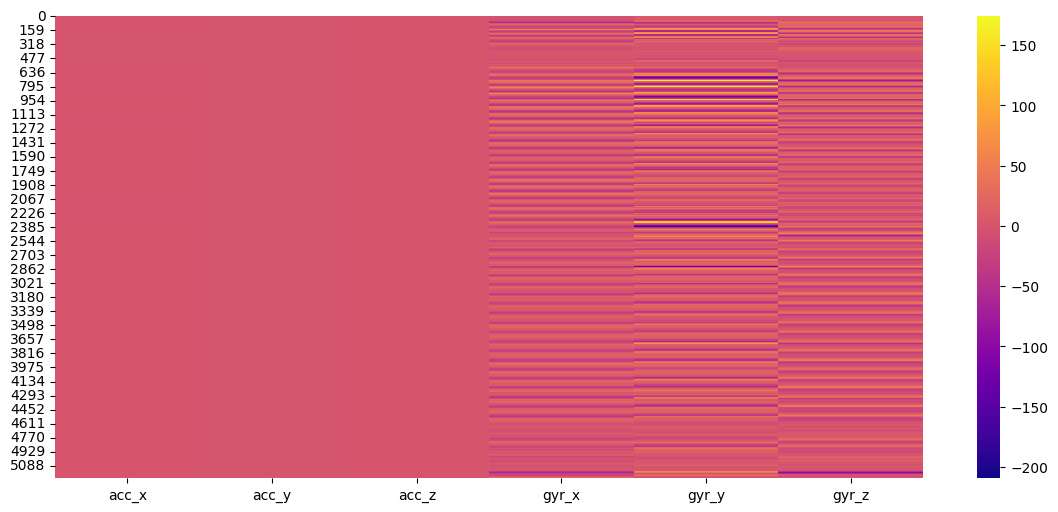

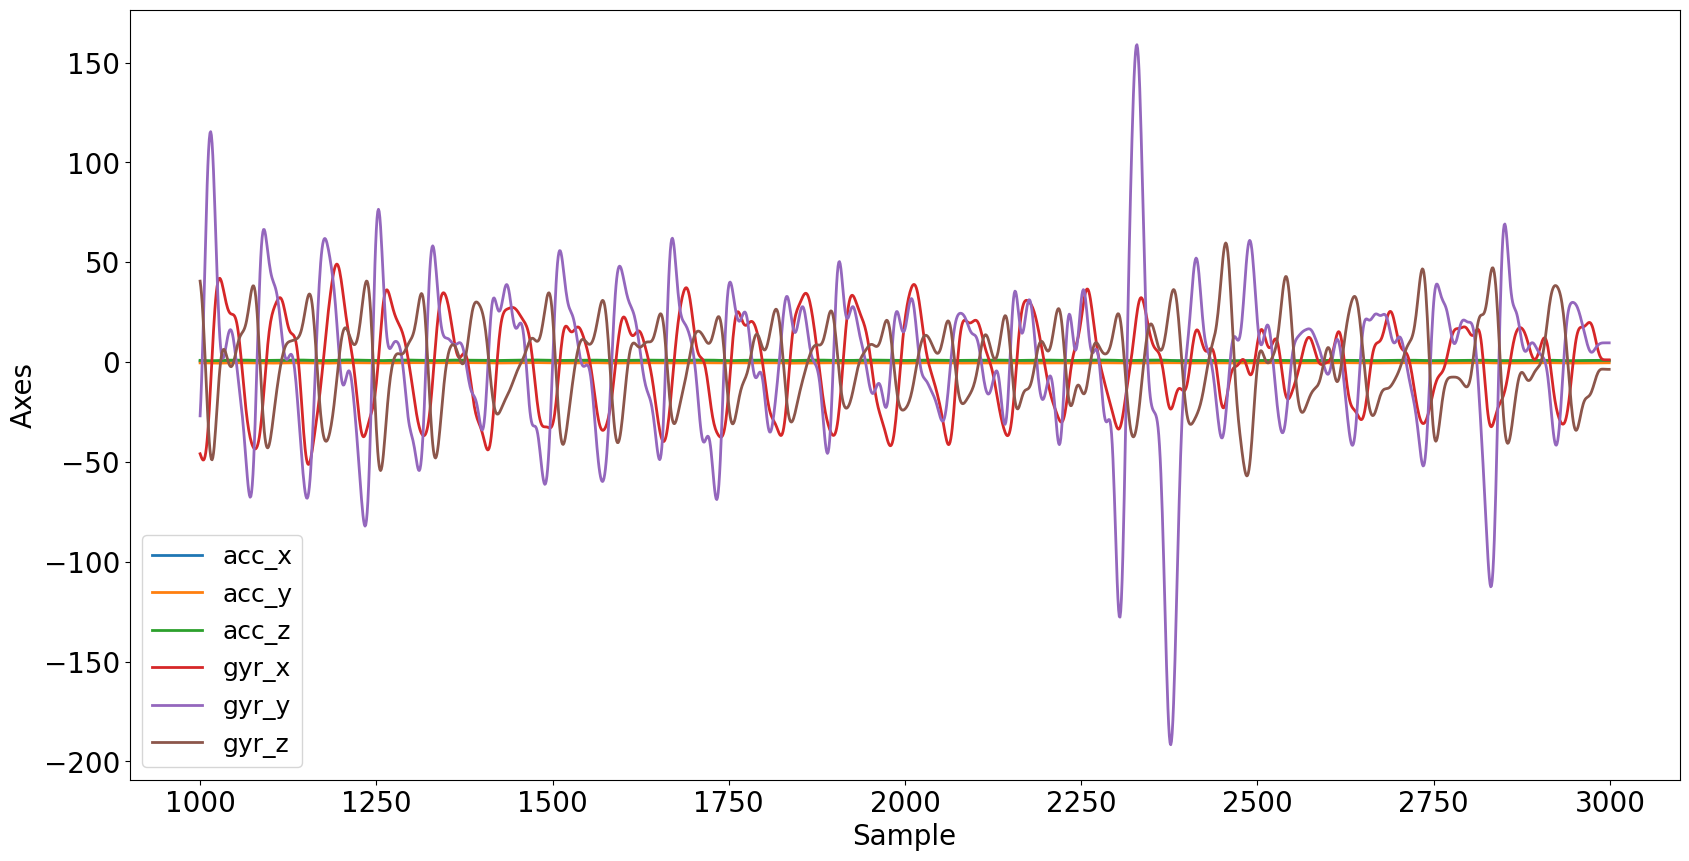

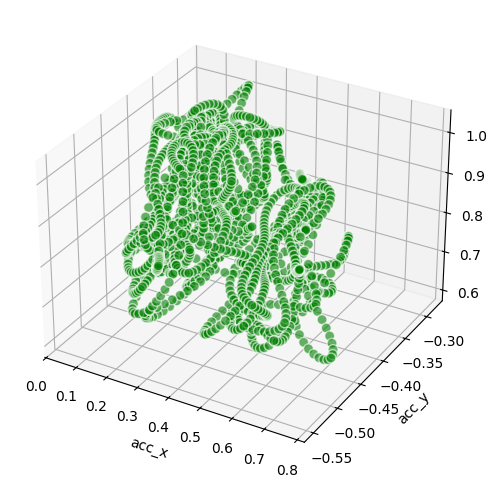

In [132]:
plot_instance_time_domain(df)
plot_instance_3d(df)
plot_heatmap(df)

# slice data into windows
clips = sliding_window_pd(df, ws=2000, overlap=1000, print_stats=True)
fclips = filter_instances(clips, order=5, wn=0.1, filter_type='lowpass')
plot_instance_time_domain(fclips[1])
plot_instance_3d(fclips[1])


Print Window: 1
Number of samples: 2000
Print Window: 2
Number of samples: 2000
Print Window: 3
Number of samples: 2000
Print Window: 4
Number of samples: 2000
List number of window instances: 4
Number of filtered instances in the list: 4


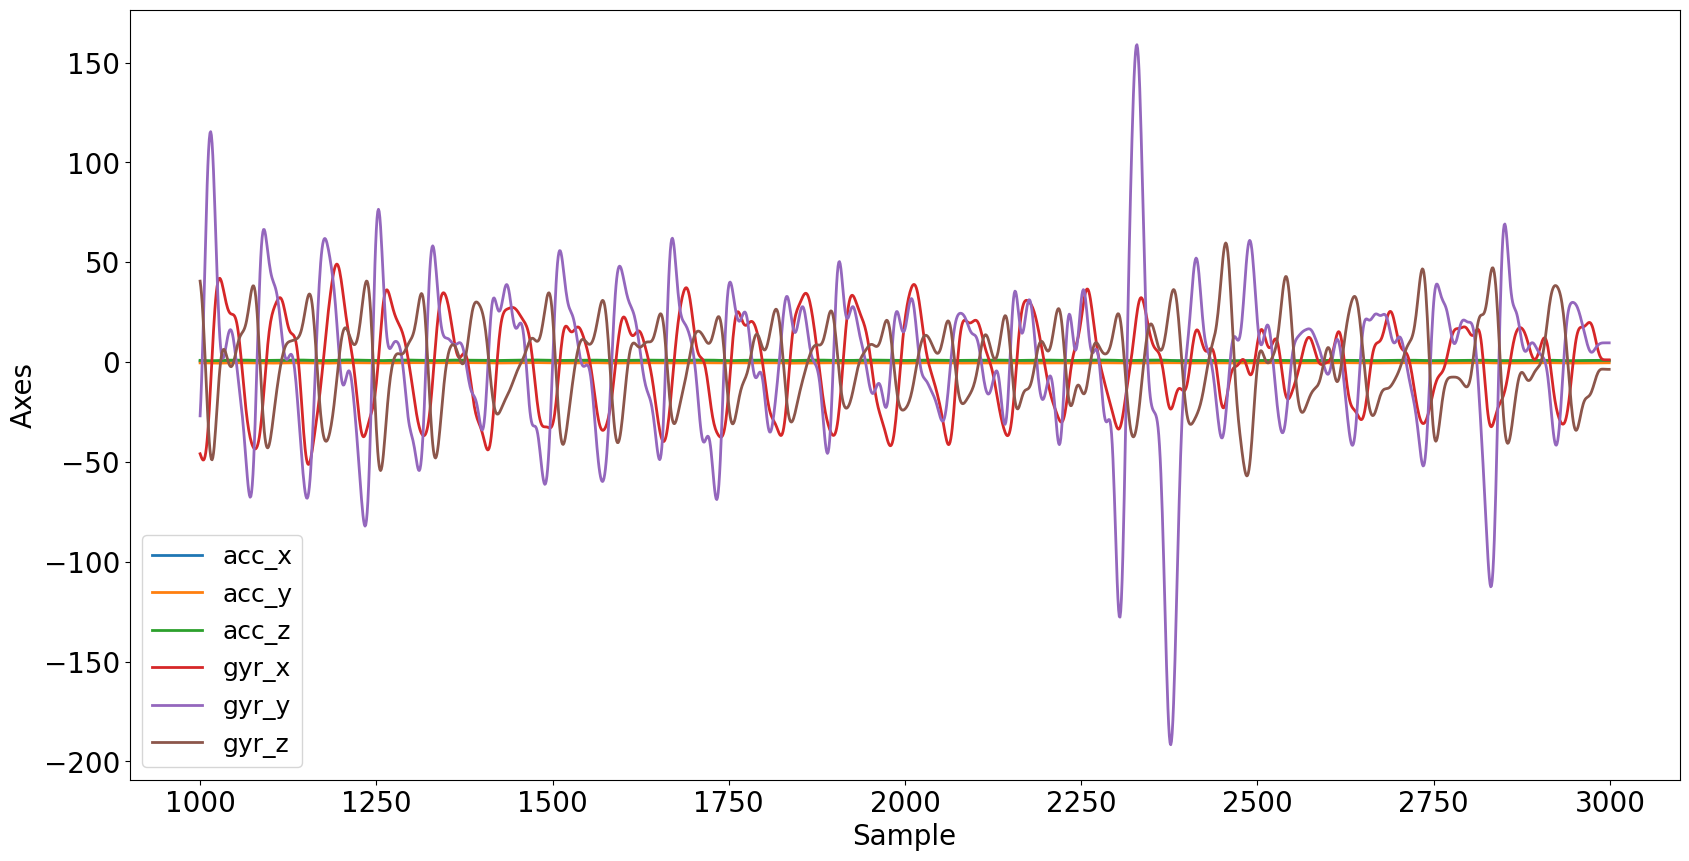

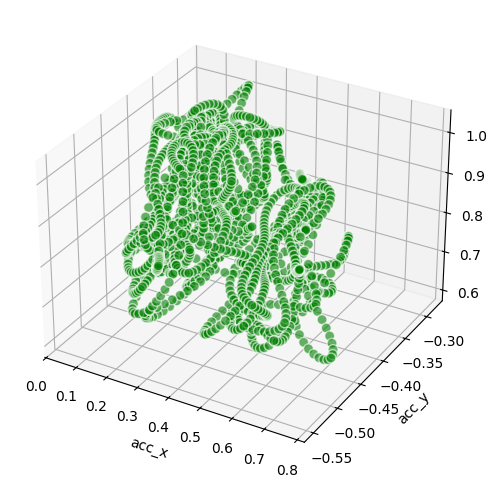

## Data Processing

## Train/Test split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=True, random_state=42)

## Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

## Classifier - Statistical Learning

### Apply simple classifier

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

### Evaluate simple classifier

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from sklearn.metrics import classification_report

### Apply optimization with Grid Search and/or Cross-validation

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

### Evaluate optimized classifier